
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E03_overfit_regularization.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Overfit and regularization exercises 

---
These are introductory exercises in Machine learning with focus in **overfitting and regularization** .

<p class = "alert alert-info" role="alert"><b>Note</b> that sometimes you don't get exactly the same answer as I get, but it doesn't neccessarily mean it is wrong. Could be some parameters, randomization, that we have different. Also very important is that in the future there won't be any answer sheets, use your skills in data analysis, mathematics and statistics to back up your work.</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Tips data EDA (*)

In the whole exercise, we will work with the "tips" dataset from seaborn dataset. Start by loading dataset "tips" from the ```load_dataset``` method in seaborn module. The goal will be to use polynomial linear regression to predict tips. 

&nbsp; a) Start by doing some initial EDA such as info(), describe().

&nbsp; b) Use describe only on those columns that are relevant to get statistical information from. Plot the descriptive statistics for each numerical column, with a adequate plot type (e.g. barplot).

&nbsp; c) Based on the initial EDA, make some more plots on things you think could be worthwhile to investigate. 

&nbsp; d) Try discuss your findings with yourself/colleague and draw some conclusions if possible. Note that in reality, it is important to be able to communicate your findings so that other people in your team/customers/stakeholders etc. get an understanding of the data and realizes the importance of your role as a data scientist/analyst.

<details>

<summary>Answer</summary>


b)
<img src="../data/df_describe.png" height="300"/>

c) Here are some example plots

<img src="../data/tips_EDA.png" height="400"/>

<img src="../data/tips_smoke_sex.png" width="600"/>

<img src="../data/tips_bar_sex.png" width="400"/>


d) For example: 
- there are almost double amount of females represented in the dataset
- there are very few tables with 1 person eating, and they usually give very low tip
- female and male tip somewhat similar

</details>

---

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = sns.load_dataset("tips")

for key in data.keys():
    print(key.upper())
    print(f"{data[key] }\n")

# A
print(data.info())
display(data.describe())
display(data.corr(numeric_only=True))

TOTAL_BILL
0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64

TIP
0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

SEX
0      Female
1        Male
2        Male
3        Male
4      Female
        ...  
239      Male
240    Female
241      Male
242      Male
243    Female
Name: sex, Length: 244, dtype: category
Categories (2, str): ['Male', 'Female']

SMOKER
0       No
1       No
2       No
3       No
4       No
      ... 
239     No
240    Yes
241    Yes
242     No
243     No
Name: smoker, Length: 244, dtype: category
Categories (2, str): ['Yes', 'No']

DAY
0       Sun
1       Sun
2       Sun
3       Sun
4       Sun
       ... 
239     Sat
240     Sat
241     Sat
242     Sat
243    Thur
Name: day, Length: 244, dtype: category
C

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


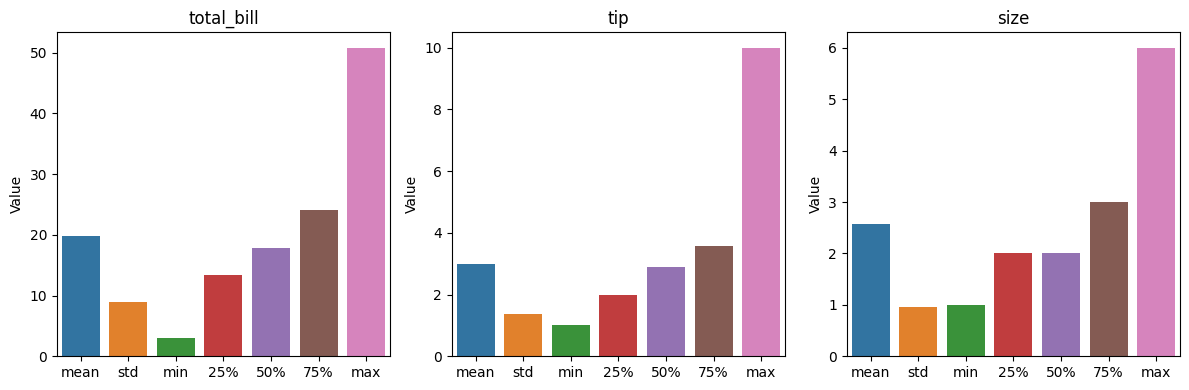

In [3]:
# B
fig, axes = plt.subplots(1, 3, figsize=(12,4))
columns = ["total_bill", "tip", "size"]

for ax, col in zip(axes, columns):
    descr = data[col].describe().drop("count")
    sns.barplot(x=descr.index, y=descr.values, ax=ax, hue=descr.index, palette="tab10")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Value")
    
plt.tight_layout()
plt.show()

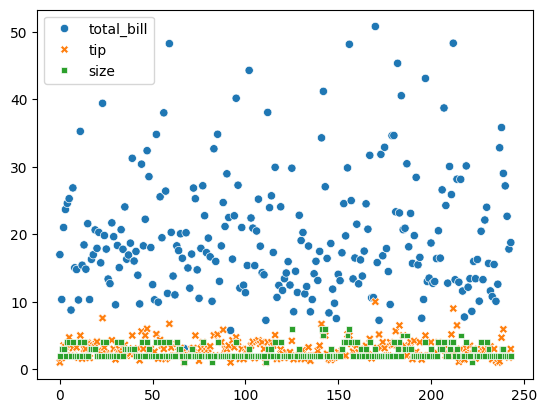

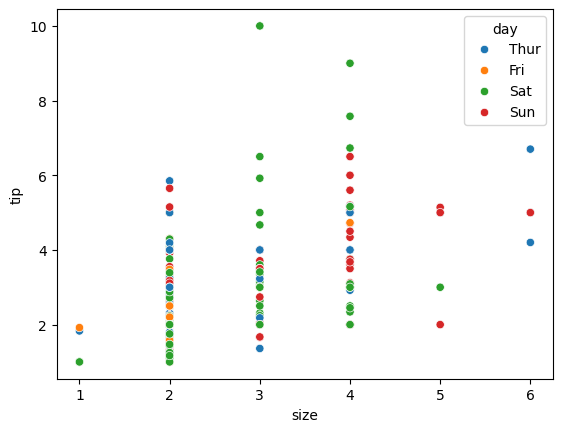

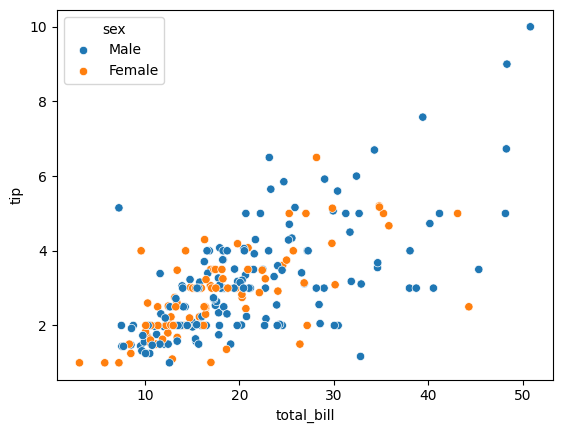

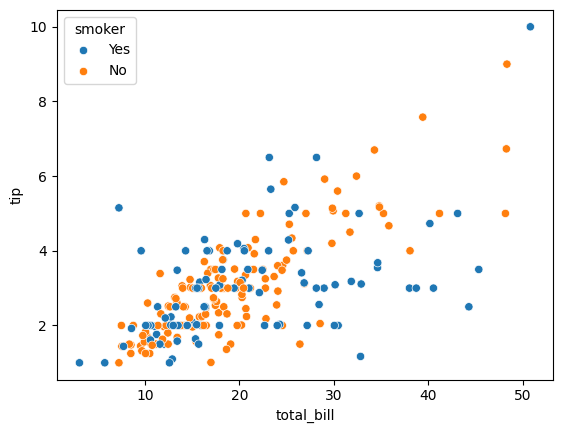

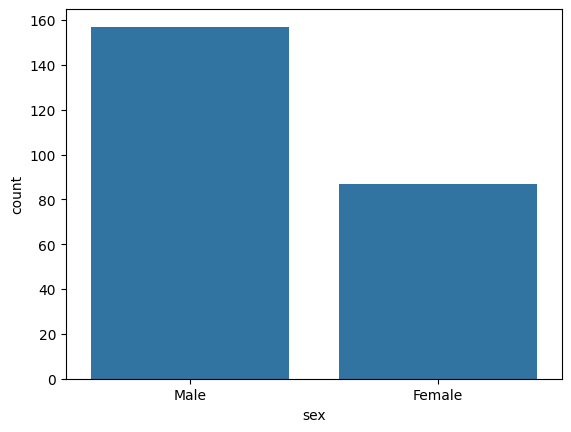

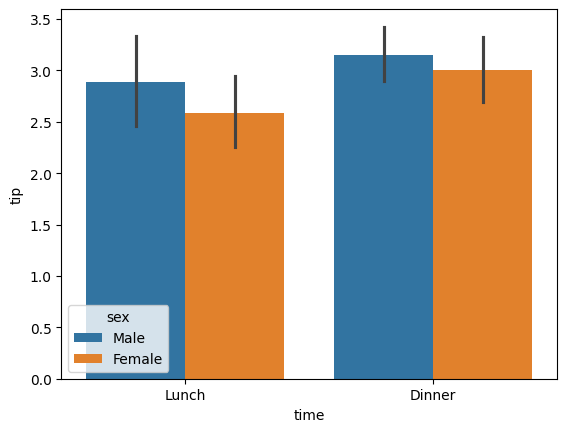

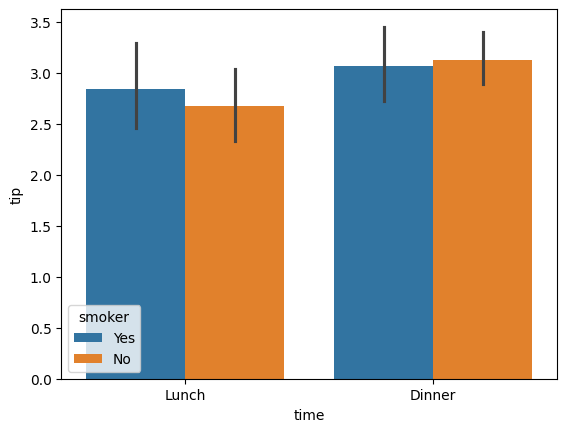

In [4]:
# C
sns.scatterplot(data)
plt.show()

sns.scatterplot(data, x="size", y="tip", hue="day")
plt.show()

sns.scatterplot(data, x="total_bill", y="tip", hue="sex")
plt.show()

sns.scatterplot(data, x="total_bill", y="tip", hue="smoker")
plt.show()

sns.barplot(data["sex"].value_counts())
plt.show()

sns.barplot(data, x="time", y="tip", hue="sex")
plt.show()

sns.barplot(data, x="time", y="tip", hue="smoker")
plt.show()

In [5]:
data["sex_binary"] = data["sex"].map({"Male": 0, "Female": 1}).astype(int)
data["smoker_binary"] = data["smoker"].map({"No": 0, "Yes": 1}).astype(int)
data["time_binary"] = data["time"].map({"Lunch": 0, "Dinner": 1}).astype(int)
data = data.drop(["sex", "smoker", "time"], axis=1)

data = pd.get_dummies(data, columns=["day"], prefix="day", drop_first=True, dtype="int")

display(data.info())

X = data.drop("tip", axis=1).copy()
y = data["tip"].copy()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   total_bill     244 non-null    float64
 1   tip            244 non-null    float64
 2   size           244 non-null    int64  
 3   sex_binary     244 non-null    int64  
 4   smoker_binary  244 non-null    int64  
 5   time_binary    244 non-null    int64  
 6   day_Fri        244 non-null    int64  
 7   day_Sat        244 non-null    int64  
 8   day_Sun        244 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 17.3 KB


None

## 1. Train|test split (*)

Split the data into training part and testing part, using sklearn's train_test_split with test size of 0.3 and random_state 42.

In [6]:
from sklearn.model_selection import train_test_split

train_X, test_X, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

---
## 2. Feature standardization (*)

We need to normalize the data and in this case will be using feature standardization. Implement this yourself following this formula:

$$X_{train}' = \frac{X_{train}-\mu_{train}}{\sigma_{train}}$$

$$X_{test}' = \frac{X_{test}-\mu_{train}}{\sigma_{train}}$$

, where $'$ denotes scaled, $\mu_{train}$ is the mean of the training data, $\sigma_{train}$ is the standard deviation of the training data. Note that it is very important that the mean and standard deviation is computed from the training data and not from testing data to avoid data leakage. Control the standard deviation and mean of $X_{train}'$ and $X_{test}'$. Is the results as you expect, why, why not?

<details>

<summary>Answer</summary>

scaled_X_train (total_bill, size) mean: [ 6.79195262e-17 -1.98534000e-16]

scaled_X_test (total_bill, size) mean: [-0.19137999 -0.04477934]

scaled_X_train (total_bill, size) std: [1. 1.]

scaled_X_test (total_bill, size) std: [0.92495673 1.06638889]

</details>

In [7]:
train_X_scaled = (train_X - train_X.mean()) / train_X.std()
test_X_scaled = (test_X - train_X.mean()) / train_X.std()

print(train_X_scaled.mean()[:2], test_X_scaled.mean()[:2])
print(train_X_scaled.std()[:2], test_X_scaled.std()[:2])

# test_X_scaled mean !~ 0 and std != 1.0. Probably because it's subtracted by train mean and std (instead of test because of data leakage).

total_bill    6.791953e-17
size         -1.985340e-16
dtype: float64 total_bill   -0.191380
size         -0.044779
dtype: float64
total_bill    1.0
size          1.0
dtype: float64 total_bill    0.924957
size          1.066389
dtype: float64


---
## 3. Polynomial features (*)

We want to investigate ```Polynomialfeatures``` from scikit-klearn in this task. Start by instantiating an object of type ```PolynomialFeatures``` with degree 2. Now do the following: 

- use the method fit on $X_{train}'$
- transform $X_{train}'$
- transform $X_{test}'$

Compare this transformed $X_{test}'$ with $X_{test}''$ where $X_{test}''$ comes from fitting the polynomial features to $X_{test}'$ and transforming $X_{test}'$. You can check directly by using ```==``` and then sum it up. If the value is same as the length, then you know that they are the same, as a boolean True evaluates to 1. 


In [8]:
from sklearn.preprocessing import PolynomialFeatures

poly_right = PolynomialFeatures(degree=2)
poly_right.fit(train_X_scaled)
poly_right.transform(train_X_scaled)
test_X_poly_r = poly_right.transform(test_X_scaled)

# Never fit() on test data! This is wrong:
poly_wrong = PolynomialFeatures(degree=2)
test_X_poly_w = poly_wrong.fit_transform(test_X_scaled)

# !=
(test_X_poly_r == test_X_poly_w).sum()

np.int64(3330)

---
## 4. Polynomial regression  (*)

We will now investigate the training loss and testing loss for different degrees of polynomial. Loop through degrees 1 to 4 (inclusive) and:
- instantiate an object of PolynomialFeatures with that degree
- fit and transform $X_{train}'$ and $X_{test}$ to create polynomial features
- perform linear regression on these polynomial features (polynomial regression)
- predict on both the training and testing data to record RMSE for training and testing for each iteration of the loop

Now plot the results in the same figure. Do you notice anything special? 

<details>

<summary>Answer</summary>

<img src="../data/E3_overfitting.png" height="400"/>

</details>

,degree,train_rmse,test_rmse
0,1,1.041051,0.965315
1,2,0.903092,1.036083
2,3,0.824722,1.242786
3,4,0.782124,2.234305


Text(0, 0.5, 'RMSE')

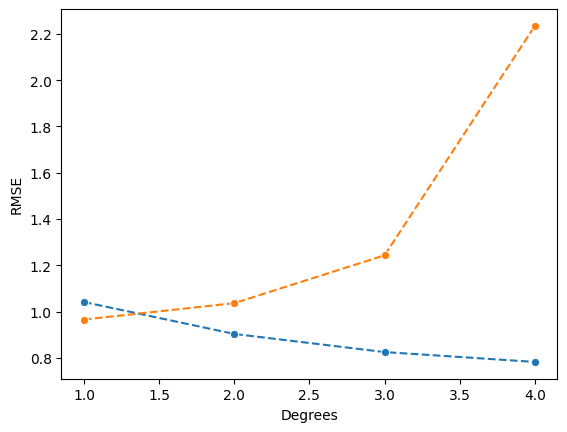

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

degrees = [1, 2, 3, 4]
train_rmses = []
test_rmses = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, interaction_only=True)
    poly.fit(train_X_scaled)
    train_X_poly = poly.transform(train_X_scaled)
    test_X_poly = poly.transform(test_X_scaled)
    
    model = LinearRegression()
    model.fit(train_X_poly, y_train)

    y_train_pred = model.predict(train_X_poly)
    y_test_pred = model.predict(test_X_poly)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_rmses.append(train_rmse)
    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_rmses.append(test_rmse)

rmse_df = pd.DataFrame({
    "degree": degrees, 
    "train_rmse": train_rmses, 
    "test_rmse": test_rmses})

display(rmse_df.head())
sns.lineplot(rmse_df, x="degree", y="train_rmse", marker=('o'), linestyle='--')
sns.lineplot(rmse_df, x="degree", y="test_rmse", marker=('o'), linestyle='--')
plt.xlabel("Degrees")
plt.ylabel("RMSE")

# Mine is already escalating after degree=1 since I've done some feature engineering on my categorical values.

---
## 5. Regularization methods (*)

Now we will try the regularization methods: ridge regression, lasso regression and elasticnet regression. In the following tasks, use degree = 4. 

&nbsp; a) Use ridge regression with cross-validation and test out different alpha-values. I used $\alpha=[0.01, 0.1, 0.5, 1, 5, 10]$ in the cross-validation. 
- Check which alpha, that the cross-validation chose as the best one. 
- Check the weights.
- Check MAE, MSE, RMSE.

&nbsp; b) Use lasso regression with cross-validation and choose number of alphas to 100. If you get a warning that the algorithm is not converging, increase the max iterations, I chose 10000 iterations. 
- Check which alpha, that the cross-validation chose as the best one. 
- Check the weights.
- Check MAE, MSE, RMSE.

&nbsp; c) Use elasticnet regression with cross-validation and choose number of alphas to 100. If you get a warning that the algorithm is not converging, increase the max iterations, I chose 10000 iterations. Choose a set of $\ell_1$ ratios for it to try out. I chose $\ell_1 = [.001, .01, .05, .1, .5, .9, .95, 1]$
- Check which alpha, that the cross-validation chose as the best one. 
- Check the weights.
- Check MAE, MSE, RMSE.

<details>

<summary>Answer</summary>

a) 

Chosen alpha from cross-validation 5.0

Weights: [ 0.          0.91469637  0.23893931 -0.67583593  0.20550801 -0.01369317
 -0.26007685  0.31867863 -0.03429744 -0.12484035  0.16000319 -0.18105113
  0.24878399 -0.12692847  0.05002613]

Mean absolute error: 0.831

Mean squared error: 2.208

Root mean squared error: 1.486

b) 

Chosen alpha from cross-validation 0.208

Weights: [ 0.          0.23469707  0.         -0.         -0.          0.
  0.08814685  0.09735986  0.          0.03219702  0.          0.
  0.         -0.          0.        ]

Mean absolute error: 0.823

Mean squared error: 1.345

Root mean squared error: 1.160

c)

Chosen alpha from cross-validation 0.107

Mean absolute error: 0.761

Root mean squared error: 1.139

L1_ratio: 0.9

Weights: [ 0.          0.23469707  0.         -0.         -0.          0.
  0.08814685  0.09735986  0.          0.03219702  0.          0.
  0.         -0.          0.        ]


</details>

In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LassoCV, ElasticNetCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric = ["total_bill", "size"]
categorical = ["sex_binary", "smoker_binary", "time_binary", "day_Fri", "day_Sat", "day_Sun"]

# A
def full_pipeline(reg_method_str, reg_method, alpha=None):
    numeric_pipeline = Pipeline([
        ("scaler", StandardScaler()), 
        ("poly", PolynomialFeatures(degree=4, include_bias=False))
    ])

    categorical_pipeline = Pipeline([
        ("onehot", OneHotEncoder(drop="first", sparse_output=False))
    ])

    preprocess = ColumnTransformer([
        ("num", numeric_pipeline, numeric), 
        ("cat", categorical_pipeline, categorical)
    ])

    model_rle = Pipeline([
        ("preprocess", preprocess), 
        (reg_method_str, reg_method)
    ])

    if alpha is not None:
        param_grid = {
            f"{reg_method_str}__alpha": alpha
        }

        scoring = {"rmse": "neg_root_mean_squared_error", 
                "mse": "neg_mean_squared_error", 
                "mae": "neg_mean_absolute_error"
                }

        grid = GridSearchCV(model_rle, param_grid, scoring=scoring, refit="rmse", cv=5)
        grid.fit(train_X, y_train)

        print("Best alpha: ", grid.best_params_)

        results = pd.DataFrame(grid.cv_results_)
        results["rmse"] = -results["mean_test_rmse"]
        results["mse"] = -results["mean_test_mse"]
        results["mae"] = -results["mean_test_mae"]

        best_alpha = grid.best_params_[f"{reg_method_str}__alpha"]
        best_row = results[results[f"param_{reg_method_str}__alpha"] == best_alpha]
        print(f"{reg_method_str.upper()}:")
        display(best_row[[f"param_{reg_method_str}__alpha", "rmse", "mse", "mae"]])
    
        print("RIDGE:")
        display(results[[f"param_ridge__alpha", "rmse", "mse", "mae"]])

        best_model = grid.best_estimator_
    
    else:
        model_rle.fit(train_X, y_train)
        best_model = model_rle
        step = best_model.named_steps[reg_method_str]
    
        print("Best alpha: ", step.alpha_)
        if reg_method_str == "elasticnet":
            print("Best l1_ratio: ", step.l1_ratio_)

        y_pred = best_model.predict(test_X)
        print("MAE:", mean_absolute_error(y_test, y_pred))
        print("MSE:", mean_squared_error(y_test, y_pred))
        print("RMSE", root_mean_squared_error(y_test, y_pred))

    step = best_model.named_steps[reg_method_str]
    feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

    coef_df = pd.DataFrame({
        "feature": feature_names, 
        "weight": step.coef_, 
        "abs_coeff": np.abs(step.coef_)
        }).sort_values("abs_coeff", ascending=False)

    print(f"{reg_method_str.upper()}:")
    display(coef_df[["feature", "weight"]])

full_pipeline(reg_method_str="ridge", reg_method=Ridge(), alpha=[0.01, 0.1, 0.5, 1, 5, 10])

# B
full_pipeline(reg_method_str="lasso", reg_method=LassoCV(max_iter=18_000, alphas=100))

# C
l1_ratio = [0.001, 0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 1.0]
full_pipeline(reg_method_str="elasticnet", reg_method=ElasticNetCV(l1_ratio=l1_ratio, alphas=100, max_iter=15000))

Best alpha:  {'ridge__alpha': 10}
RIDGE:


,param_ridge__alpha,rmse,mse,mae
5,10.0,1.212621,1.54499,0.824876


RIDGE:


,param_ridge__alpha,rmse,mse,mae
0,0.01,1.540223,2.785220,0.911260
1,0.10,1.508556,2.621841,0.905495
2,0.50,1.411448,2.175938,0.887080
3,1.00,1.342235,1.910647,0.873664
4,5.00,1.219757,1.557792,0.835092
5,10.00,1.212621,1.544990,0.824876


RIDGE:


,feature,weight
0,num__total_bill,0.725772
2,num__total_bill^2,-0.542016
6,num__total_bill^2 size,0.246757
1,num__size,0.228453
5,num__total_bill^3,-0.141942
11,num__total_bill^2 size^2,0.128659
8,num__size^3,-0.116231
9,num__total_bill^4,0.112472
10,num__total_bill^3 size,-0.105249
15,cat__smoker_binary_1,-0.091232


Best alpha:  0.2101676095425171
MAE: 0.8243753626850194
MSE: 1.3485169772521437
RMSE 1.161256637118662
LASSO:


,feature,weight
0,num__total_bill,0.229508
6,num__total_bill^2 size,0.096624
5,num__total_bill^3,0.087955
8,num__size^3,0.032025
3,num__total_bill size,-0.000000
2,num__total_bill^2,-0.000000
1,num__size,0.000000
4,num__size^2,0.000000
7,num__total_bill size^2,0.000000
9,num__total_bill^4,0.000000


Best alpha:  0.10839018107107092
Best l1_ratio:  0.9
MAE: 0.7611548010990521
MSE: 1.3001330582059054
RMSE 1.1402337734894128
ELASTICNET:


,feature,weight
0,num__total_bill,0.516285
2,num__total_bill^2,-0.211276
6,num__total_bill^2 size,0.113425
1,num__size,0.097944
9,num__total_bill^4,0.036955
8,num__size^3,0.017978
3,num__total_bill size,0.000000
4,num__size^2,0.000000
7,num__total_bill size^2,0.000000
5,num__total_bill^3,0.000000


---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---